In [1]:
import pandas as pd
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

In [2]:
# 1. Load Data
df = pd.read_csv('telemetry_log.csv')
X = df[['cpu_load', 'temperature']]

In [3]:
# 2. Train Isolation Forest
# contamination=0.05 means we expect 5% of data to be "weird"
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df['anomaly_score'] = iso_forest.fit_predict(X)

In [4]:
# 3. Identify Anomalies (Anomaly = -1, Normal = 1)
anomalies = df[df['anomaly_score'] == -1]

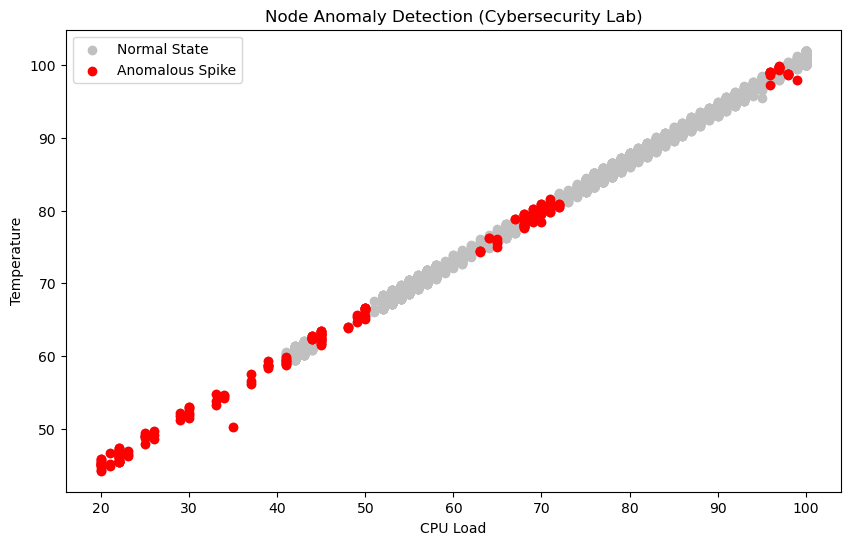

Detected 230 potential security threats or hardware malfunctions.


In [5]:
# 4. Plotting Results
plt.figure(figsize=(10,6))
plt.scatter(df['cpu_load'], df['temperature'], color='silver', label='Normal State')
plt.scatter(anomalies['cpu_load'], anomalies['temperature'], color='red', label='Anomalous Spike')
plt.title('Node Anomaly Detection (Cybersecurity Lab)')
plt.xlabel('CPU Load')
plt.ylabel('Temperature')
plt.legend()
plt.show()

print(f"Detected {len(anomalies)} potential security threats or hardware malfunctions.")